# Data Collection Visualization & Comparison

This notebook visualizes and compares the TMDB and Trakt datasets based on missing values, ratings, genres, and release years.

In [14]:
from __future__ import annotations
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ast

# Ensure plots are shown inline
%matplotlib inline

## 1. Single Dataset Visualization Functions

In [15]:
def _plot_missing_values(df: pd.DataFrame, out_dir: Path) -> Path:
    missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0].head(15)

    plt.figure(figsize=(10, 5))
    if missing_pct.empty:
        plt.text(0.5, 0.5, "No missing values", ha="center", va="center")
        plt.axis("off")
    else:
        missing_pct.plot(kind="bar")
        plt.ylabel("Missing (%)")
        plt.title("Top Missing Fields")
        plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    path = out_dir / "missing_values.png"
    plt.savefig(path, dpi=140)
    plt.show()
    plt.close()
    return path

def _plot_rating_distribution(df: pd.DataFrame, out_dir: Path) -> Path:
    plt.figure(figsize=(10, 5))
    if "rating" not in df.columns:
        plt.text(0.5, 0.5, "rating column not found", ha="center", va="center")
        plt.axis("off")
    else:
        rating_counts = df["rating"].dropna().value_counts().sort_index()
        rating_counts.plot(kind="bar")
        plt.title("Rating Distribution")
        plt.xlabel("Rating")
        plt.ylabel("Count")
        plt.xticks(rotation=0)
    plt.tight_layout()

    path = out_dir / "rating_distribution.png"
    plt.savefig(path, dpi=140)
    plt.show()
    plt.close()
    return path

def _plot_top_genres(df: pd.DataFrame, out_dir: Path) -> Path:
    plt.figure(figsize=(10, 5))
    col = "genres_list" if "genres_list" in df.columns else ("genres" if "genres" in df.columns else None)
    if col is None:
        plt.text(0.5, 0.5, "genres column not found", ha="center", va="center")
        plt.axis("off")
    else:
        def parse_genres(x):
            if not x or pd.isna(x): return []
            if isinstance(x, list): return x
            x_str = str(x)
            # Handle pipe-separated strings (common in your dataset)
            if "|" in x_str: return x_str.split("|")
            # Handle comma-separated strings
            if ", " in x_str: return x_str.split(", ")
            # Handle literal lists in strings
            try: 
                val = ast.literal_eval(x_str)
                return val if isinstance(val, list) else [str(val)]
            except: 
                return [x_str]
            
        exploded = df[col].apply(parse_genres).explode().dropna()
        top_genres = exploded.value_counts().head(10)
        if top_genres.empty:
            plt.text(0.5, 0.5, "No genres found", ha="center", va="center")
            plt.axis("off")
        else:
            top_genres.sort_values().plot(kind="barh")
            plt.title("Top 10 Genres")
            plt.xlabel("Count")
    plt.tight_layout()
    path = out_dir / "top_genres.png"
    plt.savefig(path, dpi=140)
    plt.show()
    plt.close()
    return path

def _plot_language_distribution(df: pd.DataFrame, out_dir: Path) -> Path:
    plt.figure(figsize=(8, 5))
    if "language" not in df.columns:
        plt.text(0.5, 0.5, "language column not found", ha="center", va="center")
        plt.axis("off")
    else:
        language_counts = df["language"].fillna("unknown").value_counts().head(10)
        language_counts.plot(kind="bar")
        plt.title("Top Languages")
        plt.xlabel("Language")
        plt.ylabel("Count")
        plt.xticks(rotation=0)
    plt.tight_layout()
    path = out_dir / "language_distribution.png"
    plt.savefig(path, dpi=140)
    plt.show()
    plt.close()
    return path

def _plot_release_year_distribution(df: pd.DataFrame, out_dir: Path) -> Path:
    plt.figure(figsize=(10, 5))
    col = "release_year_clean" if "release_year_clean" in df.columns else ("release_year" if "release_year" in df.columns else None)
    if col is None:
        plt.text(0.5, 0.5, "release year column not found", ha="center", va="center")
        plt.axis("off")
    else:
        year_counts = df[col].dropna().astype(int).value_counts().sort_index().tail(20)
        if year_counts.empty:
            plt.text(0.5, 0.5, "No release year data", ha="center", va="center")
            plt.axis("off")
        else:
            year_counts.plot(kind="bar")
            plt.title("Release Year Distribution (Last 20 Years Found)")
            plt.xlabel("Year")
            plt.ylabel("Count")
            plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    path = out_dir / "release_year_distribution.png"
    plt.savefig(path, dpi=140)
    plt.show()
    plt.close()
    return path

## 2. Comparison Visualization Functions

In [16]:
def _plot_comparison_missing_values(datasets: dict[str, pd.DataFrame], out_dir: Path) -> Path:
    missing_pct_by_dataset = {}
    missing_union = pd.Series(dtype=float)
    for name, df in datasets.items():
        missing_pct = (df.isna().mean() * 100)
        missing_pct_by_dataset[name] = missing_pct
        missing_union = missing_union.add(missing_pct, fill_value=0)
    top_fields = missing_union.sort_values(ascending=False).head(10).index.tolist()
    plt.figure(figsize=(12, 6))
    x = np.arange(len(top_fields))
    width = 0.35
    offsets = np.linspace(-(len(datasets)-1)*width/2, (len(datasets)-1)*width/2, len(datasets))
    for (offset, (name, missing_pct)) in zip(offsets, missing_pct_by_dataset.items()):
        y = [float(missing_pct.get(field, 0.0)) for field in top_fields]
        plt.bar(x + offset, y, width=width, label=name)
    plt.xticks(x, top_fields, rotation=45, ha="right")
    plt.title("Top Missing Fields Comparison")
    plt.ylabel("Missing (%)")
    plt.legend()
    plt.tight_layout()
    path = out_dir / "missing_values_comparison.png"
    plt.savefig(path, dpi=140)
    plt.show()
    plt.close()
    return path

def _plot_comparison_rating_distribution(datasets: dict[str, pd.DataFrame], out_dir: Path) -> Path:
    rating_indexes = set()
    counts_by_dataset = {}
    for name, df in datasets.items():
        if "rating" in df.columns:
            counts = df["rating"].dropna().value_counts().sort_index()
            counts_by_dataset[name] = counts
            rating_indexes.update(counts.index.tolist())
    plt.figure(figsize=(12, 6))
    x_vals = sorted(rating_indexes)
    x = np.arange(len(x_vals))
    width = 0.35
    offsets = np.linspace(-(len(datasets)-1)*width/2, (len(datasets)-1)*width/2, len(datasets))
    for (offset, (name, counts)) in zip(offsets, counts_by_dataset.items()):
        y = [int(counts.get(v, 0)) for v in x_vals]
        plt.bar(x + offset, y, width=width, label=name)
    plt.xticks(x, [str(v) for v in x_vals])
    plt.title("Rating Distribution Comparison")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    path = out_dir / "rating_distribution_comparison.png"
    plt.savefig(path, dpi=140)
    plt.show()
    plt.close()
    return path

def _plot_comparison_language_distribution(datasets: dict[str, pd.DataFrame], out_dir: Path) -> Path:
    lang_counts_by_dataset = {}
    all_languages = pd.Series(dtype=int)
    for name, df in datasets.items():
        if "language" in df.columns:
            counts = df["language"].fillna("unknown").value_counts()
            lang_counts_by_dataset[name] = counts
            all_languages = all_languages.add(counts, fill_value=0)
    top_languages = all_languages.sort_values(ascending=False).head(10).index.tolist()
    plt.figure(figsize=(12, 6))
    x = np.arange(len(top_languages))
    width = 0.35
    offsets = np.linspace(-(len(datasets)-1)*width/2, (len(datasets)-1)*width/2, len(datasets))
    for (offset, (name, counts)) in zip(offsets, lang_counts_by_dataset.items()):
        y = [int(counts.get(lang, 0)) for lang in top_languages]
        plt.bar(x + offset, y, width=width, label=name)
    plt.xticks(x, top_languages)
    plt.title("Top Languages Comparison")
    plt.xlabel("Language")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    path = out_dir / "language_distribution_comparison.png"
    plt.savefig(path, dpi=140)
    plt.show()
    plt.close()
    return path

def _plot_comparison_release_year_distribution(datasets: dict[str, pd.DataFrame], out_dir: Path) -> Path:
    year_index = set()
    counts_by_dataset = {}
    for name, df in datasets.items():
        col = "release_year_clean" if "release_year_clean" in df.columns else ("release_year" if "release_year" in df.columns else None)
        if col:
            counts = df[col].dropna().astype(int).value_counts().sort_index()
            counts_by_dataset[name] = counts
            year_index.update(counts.index.tolist())
    plt.figure(figsize=(12, 6))
    years = sorted(list(year_index))[-20:]
    for name, counts in counts_by_dataset.items():
        y = [int(counts.get(year, 0)) for year in years]
        plt.plot(years, y, marker="o", label=name)
    plt.title("Release Year Distribution Comparison (Latest 20 Years)")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.xticks(years, rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    path = out_dir / "release_year_distribution_comparison.png"
    plt.savefig(path, dpi=140)
    plt.show()
    plt.close()
    return path

## 3. Main Execution

### Visualizing TMDB (movie_final_dataset) ###


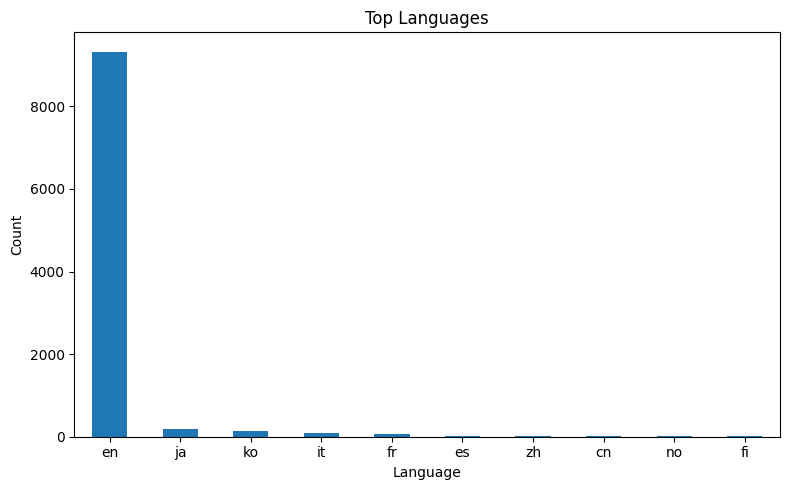

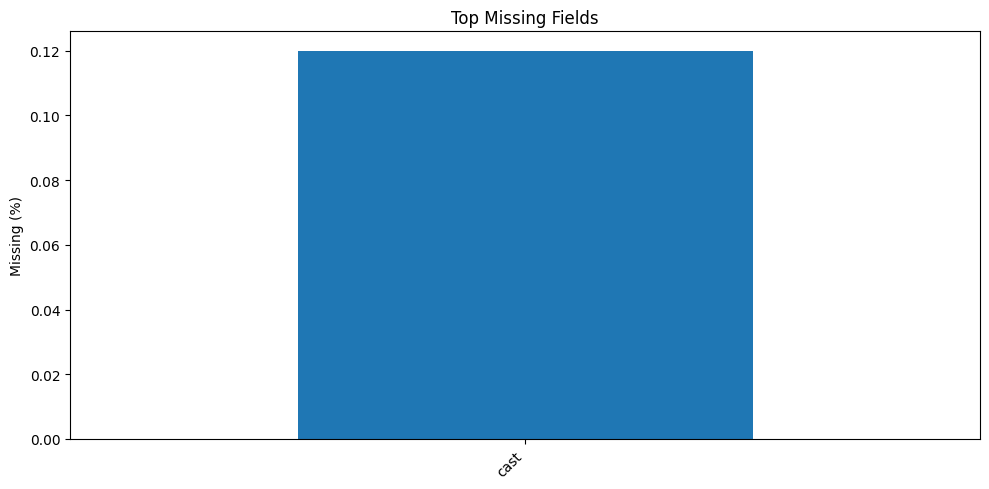

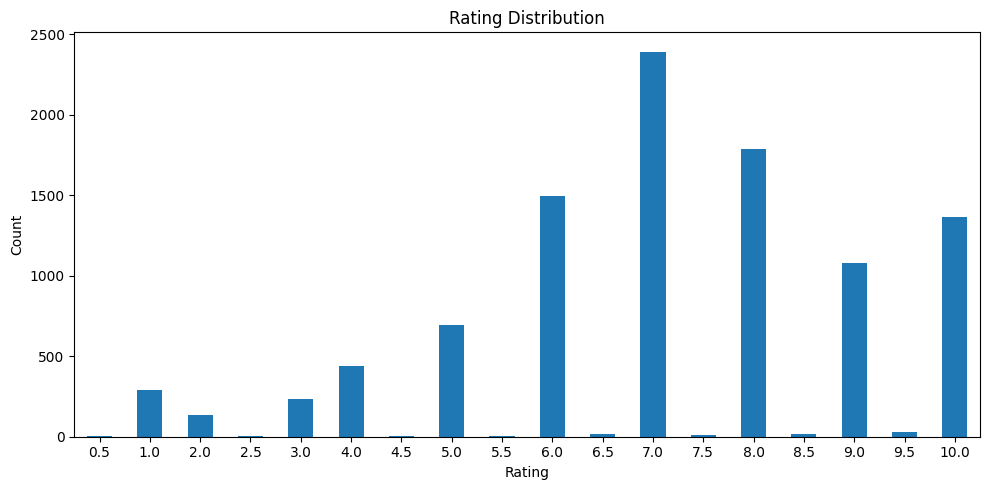

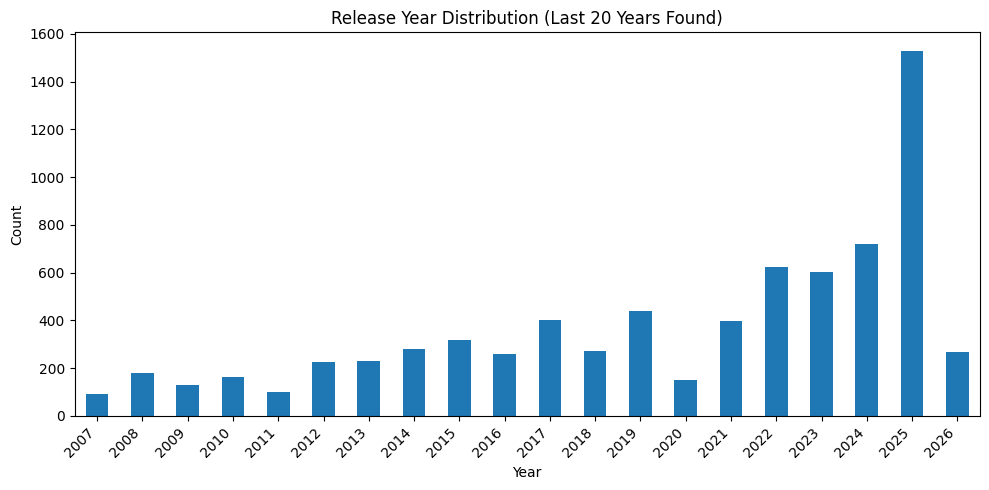

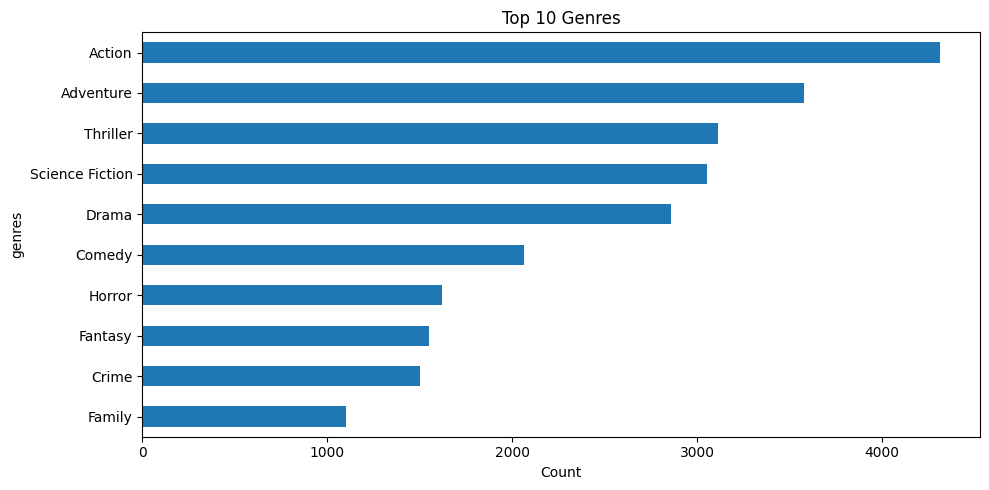


### Visualizing Trakt (trakt_ultimate_checkpoint) ###


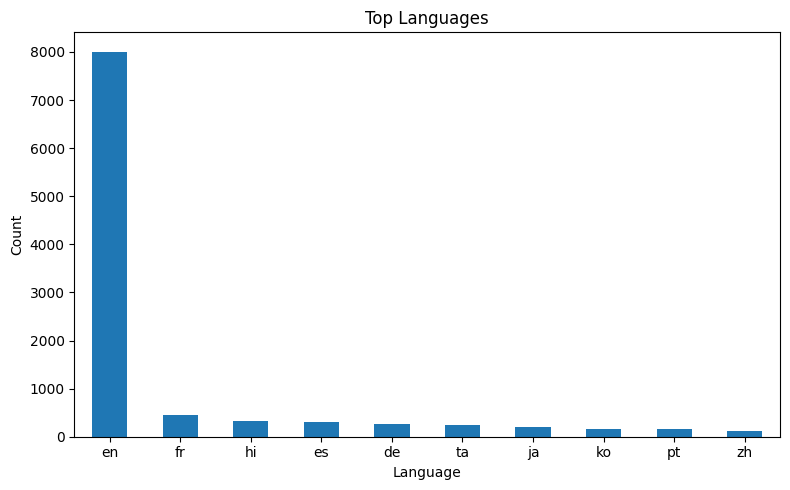

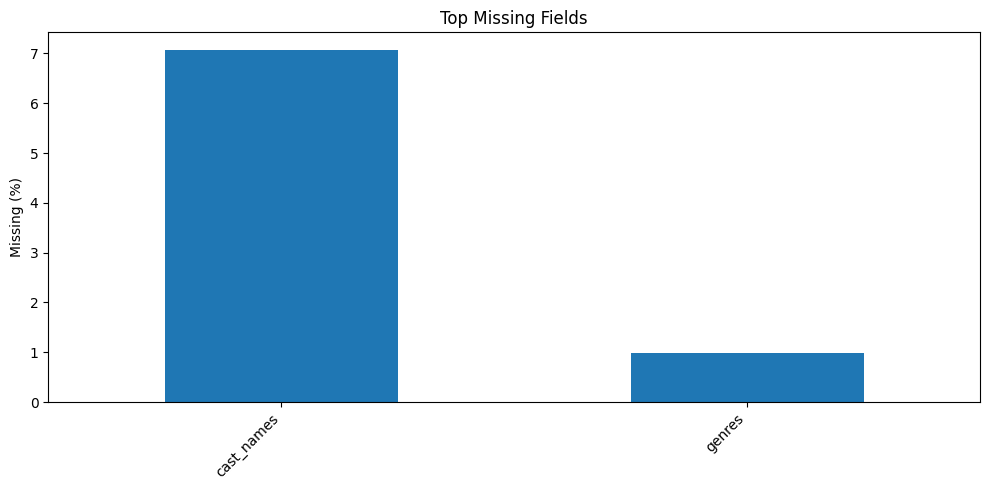

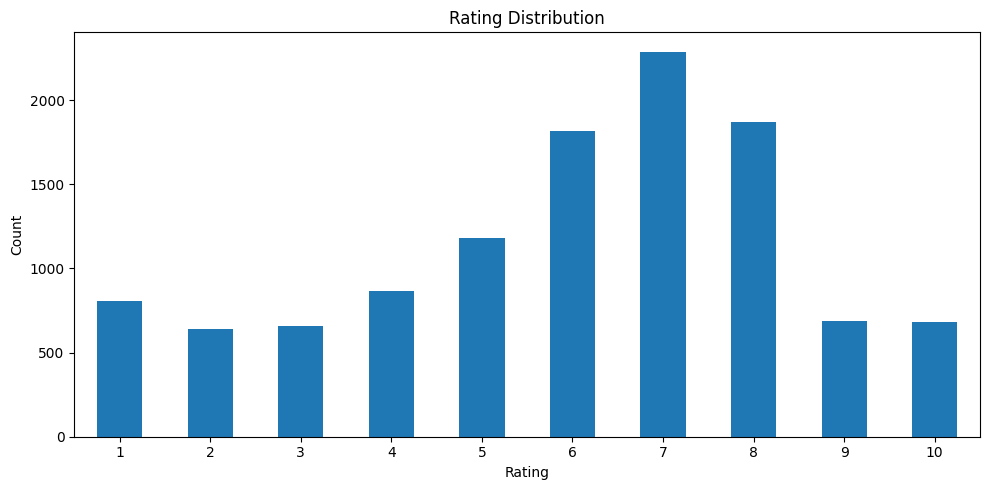

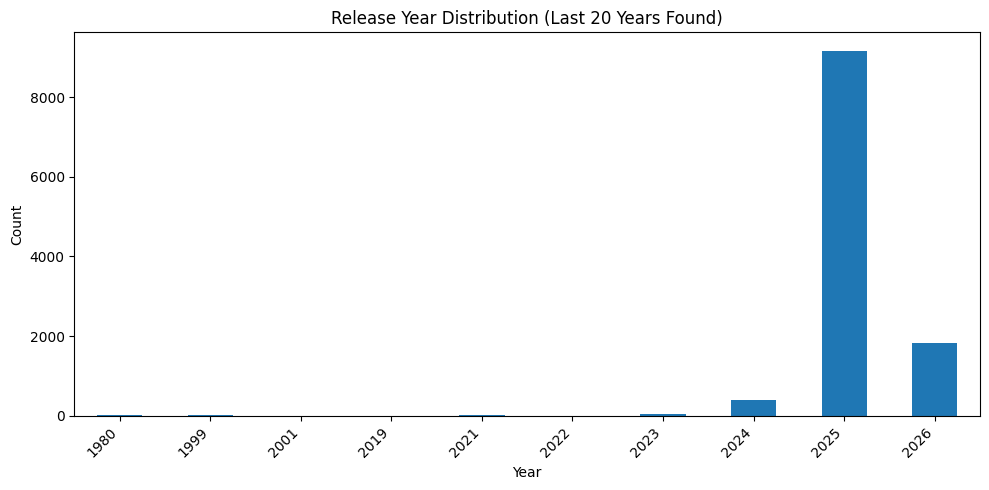

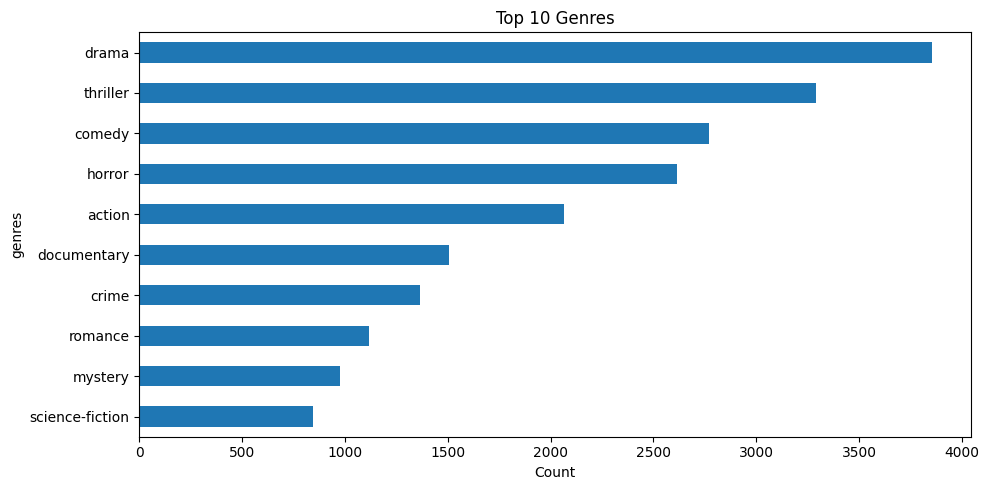


### Visualizing Comparison ###


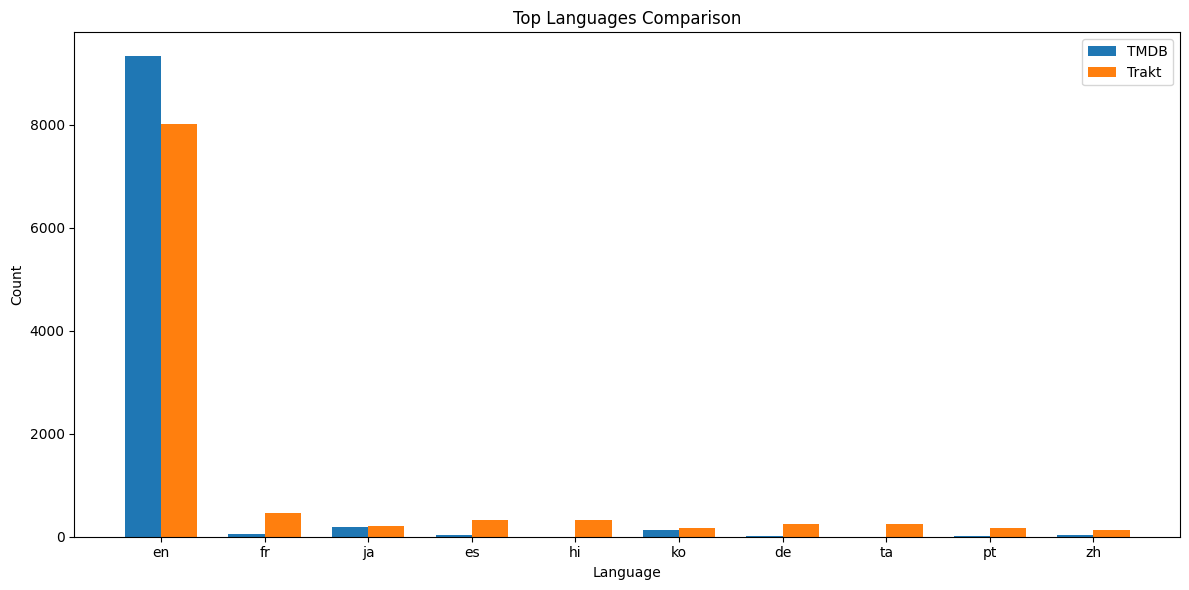

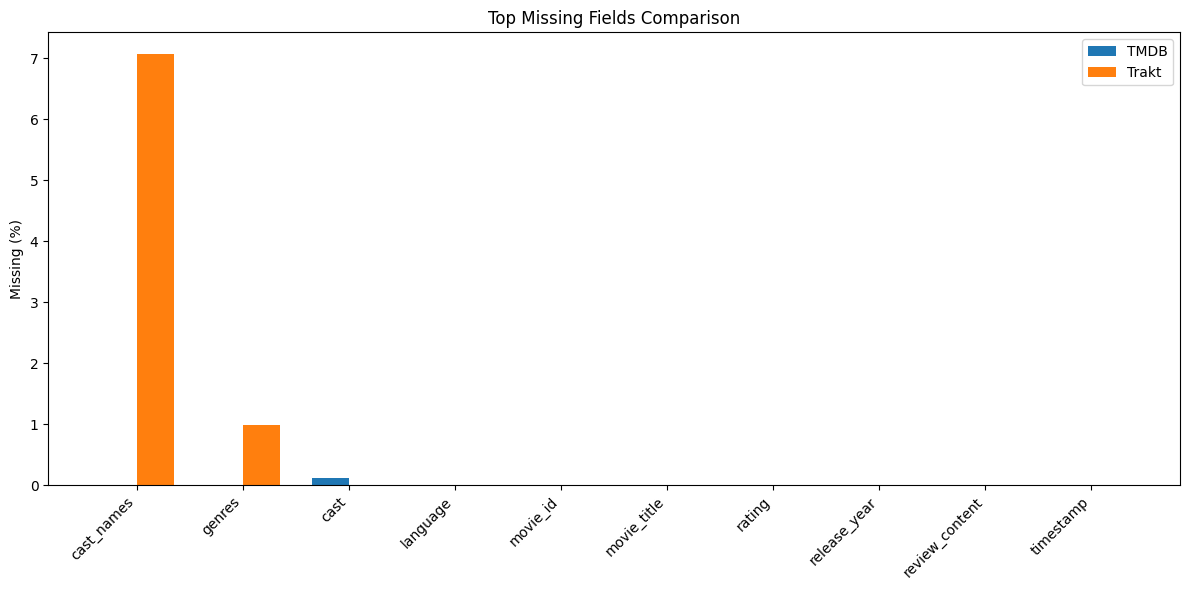

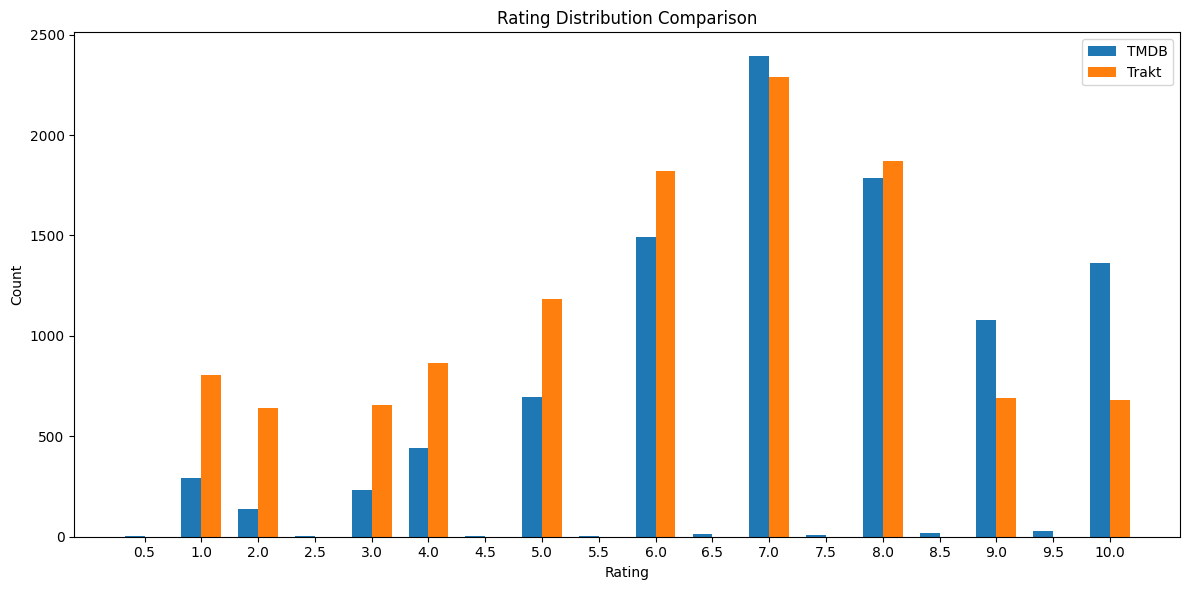

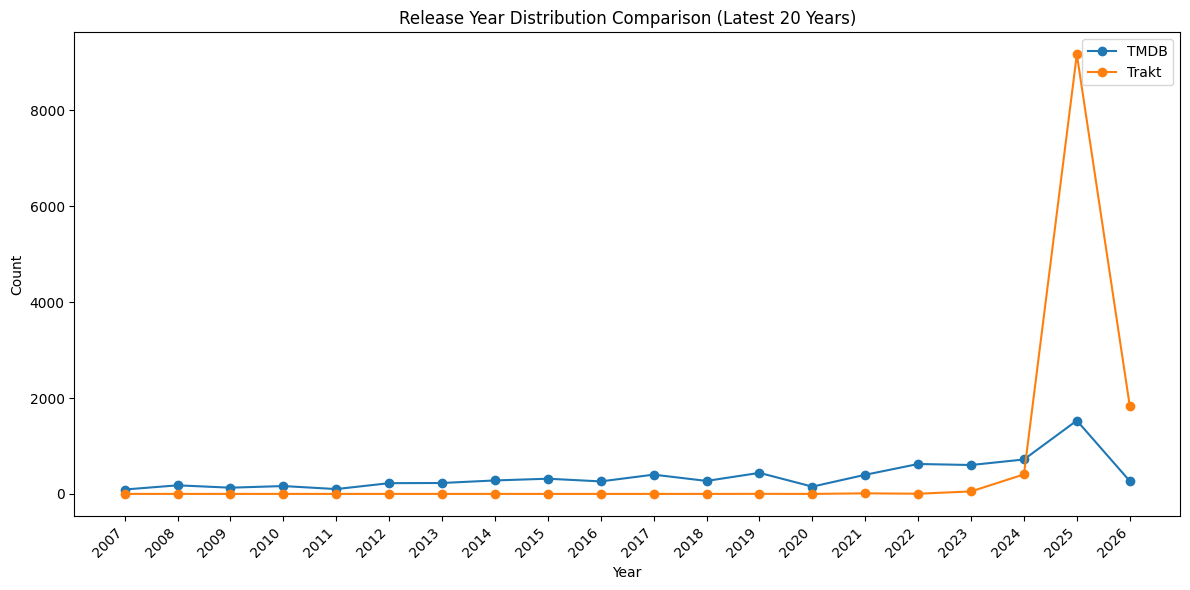

WindowsPath('d:/Smart-Movie-Recommender/outputs/figures/comparision/release_year_distribution_comparison.png')

In [17]:
BASE_DIR = Path.cwd().parent.parent
FIGURES_ROOT = BASE_DIR / "outputs" / "figures"

# Paths for single dataset visualization
TMDB_OUT = FIGURES_ROOT / "movie_final_dataset"
TRAKT_OUT = FIGURES_ROOT / "trakt_ultimate_checkpoint"
COMP_OUT = FIGURES_ROOT / "comparision"

for p in [TMDB_OUT, TRAKT_OUT, COMP_OUT]: p.mkdir(parents=True, exist_ok=True)

# Load datasets
tmdb_df = pd.read_csv(BASE_DIR / "data" / "movie_final_dataset.csv")
trakt_df = pd.read_csv(BASE_DIR / "data" / "trakt_ultimate_checkpoint.csv")

# 1. Visualize TMDB
print("### Visualizing TMDB (movie_final_dataset) ###")
_plot_language_distribution(tmdb_df, TMDB_OUT)
_plot_missing_values(tmdb_df, TMDB_OUT)
_plot_rating_distribution(tmdb_df, TMDB_OUT)
_plot_release_year_distribution(tmdb_df, TMDB_OUT)
_plot_top_genres(tmdb_df, TMDB_OUT)

# 2. Visualize Trakt
print("\n### Visualizing Trakt (trakt_ultimate_checkpoint) ###")
_plot_language_distribution(trakt_df, TRAKT_OUT)
_plot_missing_values(trakt_df, TRAKT_OUT)
_plot_rating_distribution(trakt_df, TRAKT_OUT)
_plot_release_year_distribution(trakt_df, TRAKT_OUT)
_plot_top_genres(trakt_df, TRAKT_OUT)

# 3. Comparison
print("\n### Visualizing Comparison ###")
datasets = {"TMDB": tmdb_df, "Trakt": trakt_df}
_plot_comparison_language_distribution(datasets, COMP_OUT)
_plot_comparison_missing_values(datasets, COMP_OUT)
_plot_comparison_rating_distribution(datasets, COMP_OUT)
_plot_comparison_release_year_distribution(datasets, COMP_OUT)